# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset and inspect structure; handle missing values and inconsistent data

In [3]:
df=pd.read_excel(r"C:\Users\kd940\OneDrive\Documents\Online Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [6]:
df.shape

(541909, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [8]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df[["Quantity","UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [10]:
mode=df[df["Description"].notnull()]["Description"].mode()[0]
df["Description"]=df["Description"].fillna(mode)

In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df=df.dropna(subset=['CustomerID'])

In [14]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

Which InvoiceNo is starting with C is a cancelled orders so we should remove them

In [15]:
is_all_positiv = (df['Quantity'] > 0).all()
is_all_positiv

np.True_

In [16]:
is_all_positive = (df['UnitPrice'] > 0).all()
is_all_positive

np.False_

In [17]:
df=df[df['UnitPrice']>0] 

In [18]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 392692, dtype: datetime64[us]

In [19]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

# # Descriptive statistics: average purchase value, purchase frequency, customer lifetime value


In [20]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [21]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [22]:
total_revenue = df['TotalPrice'].sum()

total_transactions = df['InvoiceNo'].nunique()

average_purchase_value = total_revenue / total_transactions

print(f"Average Purchase Value: {average_purchase_value:.2f}")

Average Purchase Value: 479.56


A customer spends average amount 373.07 in one transaction.

In [23]:
total_transactions = df['InvoiceNo'].nunique()

total_customers = df['CustomerID'].nunique()

purchase_frequency = total_transactions / total_customers

print(f"Purchase Frequency: {purchase_frequency:.2f}")

Purchase Frequency: 4.27


Average number of transactions per customer.

In [24]:
customer_lifetime_value = average_purchase_value * purchase_frequency

print(f"Estimated Customer Lifetime Value: {customer_lifetime_value:.2f}")

Estimated Customer Lifetime Value: 2048.69


Approximate 1893.53 revenue generated by an average customer over their relationship with the busines.

# Feature selection: identify 2–3 key behavioural features for clustering (e.g., Recency, Frequency, Monetary — RFM analysis)

In [25]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [26]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [27]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [28]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [29]:
rfm_scaled = pd.DataFrame(rfm_scaled,columns=rfm.columns,index=rfm.index)

In [30]:
rfm_scaled

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812
...,...,...,...
18280.0,1.854587,-0.425097,-0.207931
18281.0,0.884612,-0.425097,-0.219037
18282.0,-0.845342,-0.295178,-0.208214


In [31]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

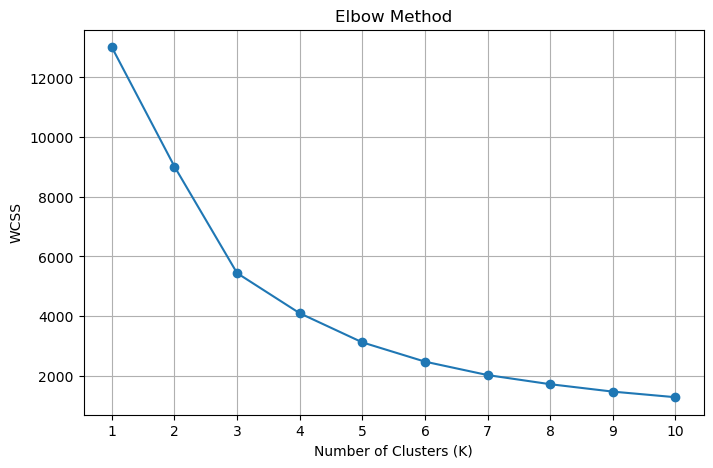

In [32]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

##### Interpretation: The curve shows that as the value of k Increases Within-Cluster Sum of Squares Decreases and a distinct bend at K=3 indicating that three clusters provide a good balance between minimizing within-cluster variance and avoiding unnecessary model complexity.

In [33]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [34]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


In [35]:
rfm['Cluster'].value_counts()

Cluster
1    3230
0    1082
2      26
Name: count, dtype: int64

number of custemers in each cluster

In [36]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,247.11,1.58,629.66
1,41.45,4.67,1849.67
2,6.04,66.42,85826.08


## Interpretation of RFM : 
##### Cluster 0 – Lost Customers

##### Cluster 1– Regular Customers

##### Cluster 2 – Premium Customers

##### Buissness Conclusion: 
The K-Means clustering algorithm identified three distinct customer segments. Cluster 2 represents the most valuable customers, characterized by recent purchases, high purchase frequency, and the highest total spending. These customers should be prioritized with retention and loyalty strategies. Cluster 1 consists of regular customers who can be encouraged to spend more through targeted promotions and loyalty programs. Cluster 0 contains inactive customers who have not made purchases recently and require re-engagement campaigns to reduce customer churn.

# Visualise clusters using scatter plots (at least 2 feature combinations)


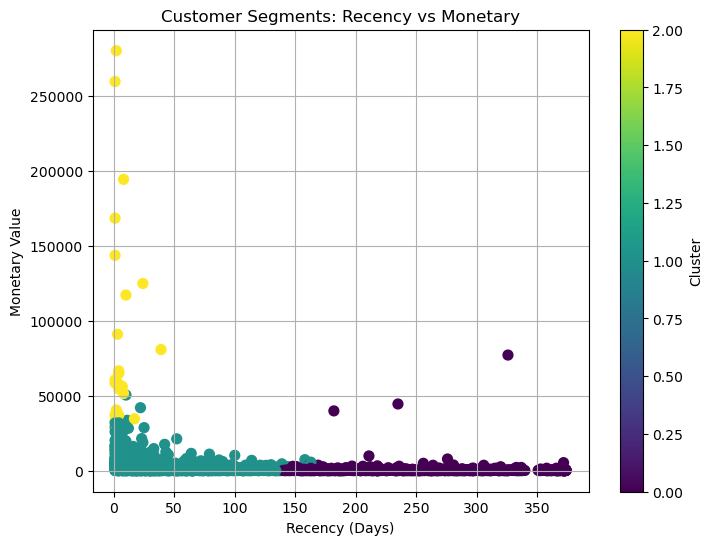

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    s=50
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

## Interpretation: 
The scatter plot shows a clear separation between high-value and low-value customers. Customers with lower recency (recent purchases) and higher monetary values belong to the premium segment, while customers with high recency and low spending are identified as lost customers.

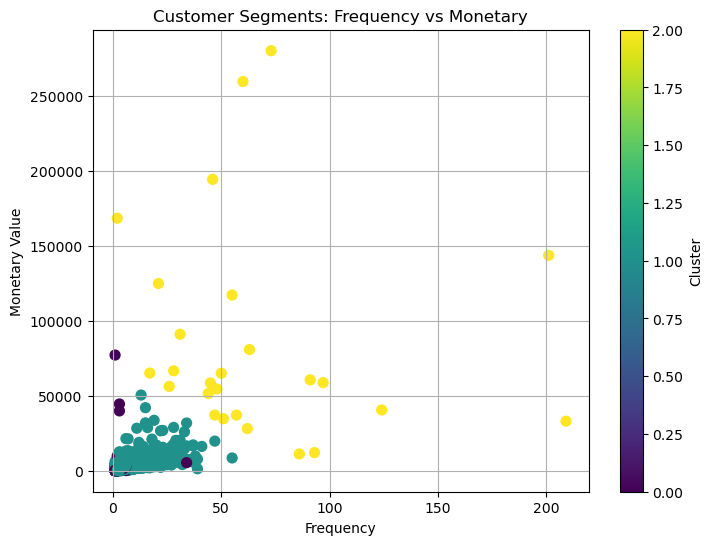

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    s=50
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

## Interpretation:
This visualization demonstrates a positive relationship between purchase frequency and total spending. Customers who purchase more frequently also tend to generate higher revenue, making them the most valuable segment for the business.

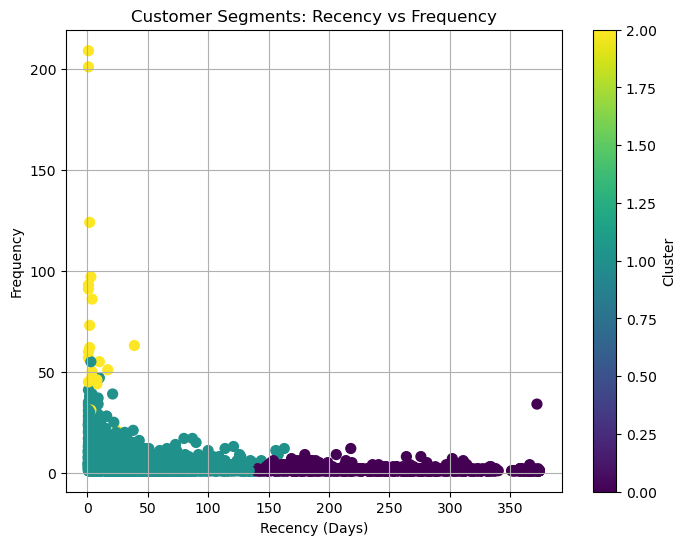

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    c=rfm['Cluster'],
    cmap='viridis',
    s=50
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Frequency")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

## Interpretaion
The majority of customers fall into the Regular and Dormant segments, a relatively small number of highly active customers (Cluster 2) are responsible for a disproportionately large share of purchases. This follows the Pareto Principle (80/20 Rule), where a small percentage of customers often generates most of the revenue.

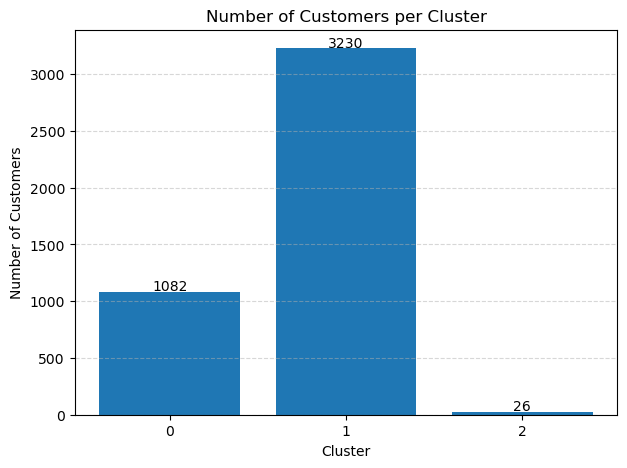

In [40]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

for i, value in enumerate(cluster_counts.values):
    plt.text(i, value+10, str(value), ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Interpretation
Approximately 74% of customers (3,230 customers) belong to Cluster 1, making it the largest customer segment, 
Around 25% of customers (1,082 customers) belong to Cluster 0, indicating low purchase frequency and long periods since their last transaction, Only 26 customers (approximately 1%) belong to Cluster 2, making it the smallest customer segment.

## Marketing Action Recommondations:

##### Cluster 0 – Lost Customers
Offer attractive discounts or cashback to encourage another purchase,
Ask for customer feedback to understand why they stopped buying,
Retarget them through social media or email campaigns.

##### Cluster 1– Regular Customers 
Encourage them to become premium customers through exclusive offers, offer seasonal promotions, introduce them with rewards program.

##### Cluster 2 – Premium Customers
Provide VIP membership benefits and exclusive discounts,
Give early access to new products and special sales,
Offer personalized product recommendations.

# Task 2 Complete